Critical Chi-Square Value: 3.841458820694124
Profile Likelihoods V2


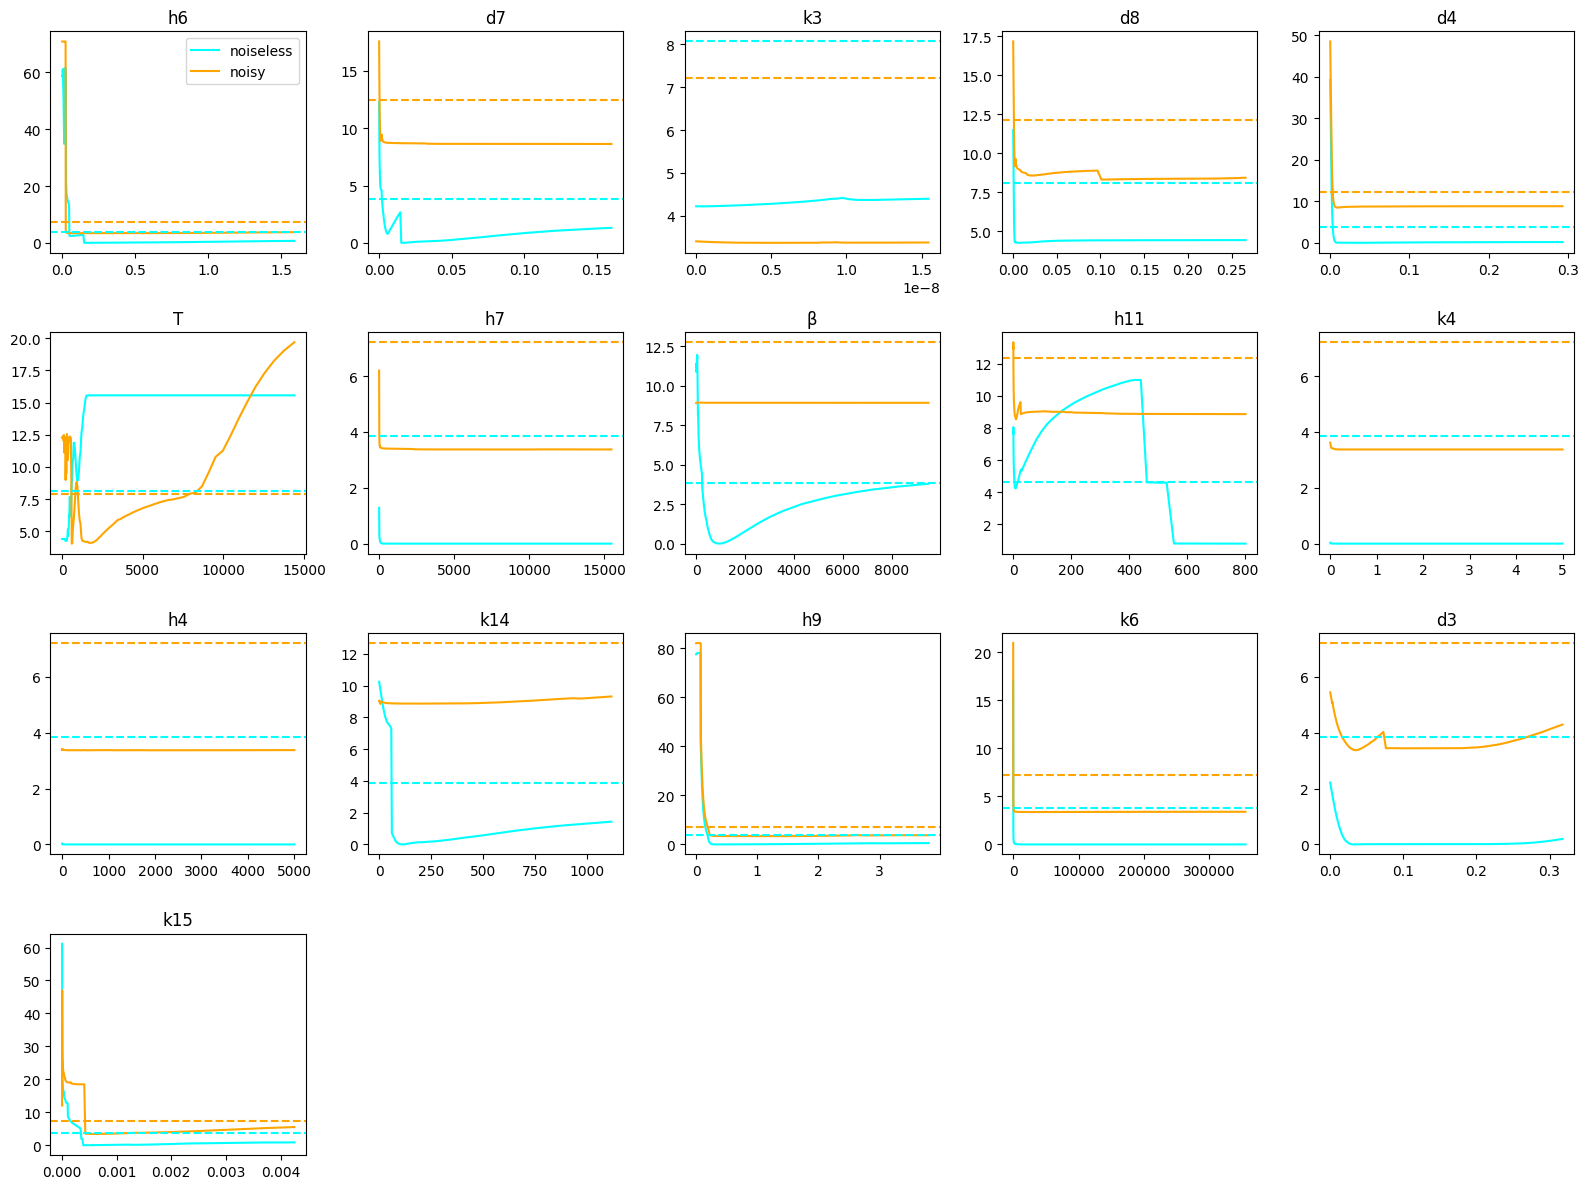

In [4]:
import pickle
import matplotlib.pyplot as plt
import numpy as np

param_titles = ['d1',
'k1','k2','h1','h2','h3','d2',
'k3','k4','h4','d3',
'h5','h6','k5','k6','h7','d4',
'b1','k7','h8','k8','h9','d5','h10',
'b2','k9','k10','k11','d6',
'k12','k13','k14','h11','d7',
'k15','k16','d8',
'\u03B1', 'k', '\u03B2', 'L', '\u03B5', '\u03B4', 'T', 'Nc']

# from PL_theiaprep import param_global_all

D = '3'         # '1' for ACTH + Cort,
                # '2' for ACTH + Cort + TNF-a
                # '3' for ACTH + Cort + TNF-a + IL10
dpoints = '2'   # '1' for 25, '2' for 13
N = 'nonoise'   #'noisy' or 'nonoise'. Not perfect, some paths may need to be tweaked.


if D == '1':
    output_ids = [6,7]
elif D == '2':
    output_ids = [3,6,7]
else:
    output_ids = [3,4,6,7]

with open('PL_results_V2\\PL_' + D + dpoints + 'nonoise.pkl', 'rb') as f:
    results1 = pickle.load(f)

# all_results = {
#     'param_ids' : param_ids,
#     't_data' : t_data,
#     'y_data' : y_data,
#     'true_sol' : true_sol,
#     'J_save': J_save,
#     'par_save': par_save,
#     'param_global_all': param_global_all
# }
#
param_ids1 = results1['param_ids']
t_data1 = results1['t_data']
y_data1 = results1['y_data']
true_sol1 = results1['true_sol']
J_save1 = results1['J_save'].copy()
par_save1 = results1['par_save'].copy()


with open('PL_results_V2\\PL_' + D + dpoints + 'noisy.pkl', 'rb') as f:
    results2 = pickle.load(f)

param_ids2 = results2['param_ids']
t_data2 = results2['t_data']
y_data2 = results2['y_data']
true_sol2 = results2['true_sol']
J_save2 = results2['J_save'].copy()
par_save2 = results2['par_save'].copy()

from scipy.stats import chi2
#
alpha = 0.05  # Significance level
df = 1        # Degrees of freedom

# Calculate the critical value
critical_value = chi2.ppf(1 - alpha, df)

print(f"Critical Chi-Square Value: {critical_value}")

# for i in range(len(param_ids)):
#
#     plt.figure()
#     plt.title(paramtitles[param_ids[i]])
#     plt.plot(par_save[i,i,:],J_save[i,:])
#     plt.axhline(y=critical_value, color='r')
#     plt.show()

if param_ids1 != param_ids2:
    print("PARAM ORDER DOES NOT MATCH")

fig, axs = plt.subplots(4,5, figsize = (16,12))
CI = np.zeros((20,2))
for i in range(4):

    for k in range(5):
        if i*5 + k>= len(param_ids1):
            for r in range(k,5):
                axs[i,r].remove()
            break

        axs[i, k].plot(np.exp(par_save1[i*5 + k,i*5 +k,:]),J_save1[i*5 + k,:], label = "noiseless", color = 'cyan')
        axs[i, k].plot(np.exp(par_save2[i*5 + k,i*5 +k,:]),J_save2[i*5 + k,:], label = "noisy", color = 'orange')
        axs[i, k].axhline(y=critical_value+np.min(J_save1[i*5 + k,:]), color='cyan', linestyle='--')
        axs[i, k].axhline(y=critical_value+np.min(J_save2[i*5 + k,:]), color='orange', linestyle='--')
        axs[i,k].set_title(param_titles[param_ids1[i*5 + k]])
# for ax in axs.flat:
#     ax.set_xticks([])
axs[0,0].legend()
fig.tight_layout()
#fig.savefig('FIGS\\PL_results_' + N + D + dpoints + '.png')
print("Profile Likelihoods V2")